In [19]:
from sklearn.datasets import fetch_openml
from sklearn.datasets import load_digits
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, ShuffleSplit
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, precision_score, recall_score, f1_score
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import classification_report

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from sklearn.svm import SVR,SVC,NuSVC
import cv2
from skimage.io import imread, imshow
from skimage.transform import resize
from skimage.feature import hog
from skimage import exposure
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
from IPython import display
from sklearn.manifold import TSNE
import os

%matplotlib inline


In [20]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("antigs/skyimage-dataset")

print("Path to dataset files:", path)

Path to dataset files: /home/mary/.cache/kagglehub/datasets/antigs/skyimage-dataset/versions/1


In [21]:
def process_images_from_folder_HOG_only_gr(folder_path):
    image_vectors = []
    file_names = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
    
    for file_name in file_names:
        file_path = os.path.join(folder_path, file_name)
        try:
            image = imread(file_path)
            image = cv2.resize(image, (64,64))
            image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY )
            #print(image.ravel().shape)
            fd, hog_image = hog(image, orientations=9, pixels_per_cell=(8, 8), 
                    cells_per_block=(2, 2), visualize=True)
            #d = np.concatenate(image.ravel(),fd)
            d = np.array(fd)
            image_vectors.append(d)
        except Exception as e:
            print(f"Ошибка при обработке файла {file_name}: {e}")
            
    return image_vectors


In [22]:
view = {0 : 'Far', 1 : 'Left', 2 : 'MiddleClose', 3 : 'Right'}
path = './data/non-vehicles/'
res_non_vehicle_HOG = []
for cls in view:
    path_using = path + view[cls] + '/'
    res_non_vehicle_HOG += process_images_from_folder_HOG_only_gr(path_using)
#res_non_vehicle_HOG

In [23]:
#в скобочках просто path - если сделали импорт с кагла как выше - не нужно путь в кавычках прописывать
res_non_vehicle_HOG += process_images_from_folder_HOG_only_gr("/home/mary/.cache/kagglehub/datasets/antigs/skyimage-dataset/versions/1/swimseg-2/train")

In [24]:
view = {0 : 'Far', 1 : 'Left', 2 : 'MiddleClose', 3 : 'Right'}
path = './data/vehicles/'
res_vehicle_HOG = []
for cls in view:
    path_using = path + view[cls] + '/'
    res_vehicle_HOG += process_images_from_folder_HOG_only_gr(path_using)
#res_vehicle_HOG


In [25]:
res_non_vehicle_HOG = np.array(res_non_vehicle_HOG)
res_vehicle_HOG = np.array(res_vehicle_HOG)

In [53]:
res_non_vehicle_HOG.shape

(4801, 1764)

In [70]:
import random
random.shuffle(res_non_vehicle_HOG)
res_non_vehicle_HOG = res_non_vehicle_HOG[:3500]

In [74]:
res_non_vehicle_HOG.shape

(3500, 1764)

In [72]:
res_vehicle_HOG.shape

(3425, 1764)

In [75]:
y = np.concatenate((np.ones(res_vehicle_HOG.shape[0]), np.zeros(res_non_vehicle_HOG.shape[0])))

In [76]:
X = np.vstack((res_vehicle_HOG, res_non_vehicle_HOG))

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

(array([692.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 693.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

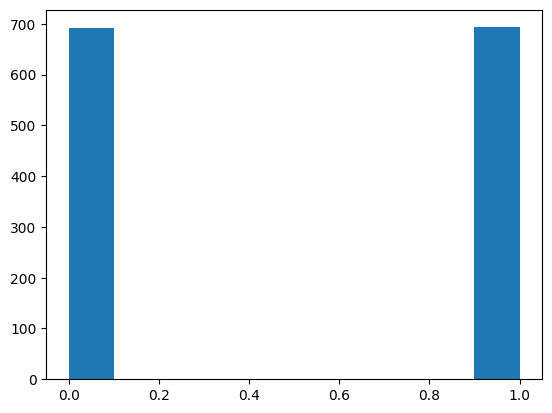

In [78]:
plt.hist(y_test)

(array([2808.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        2732.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

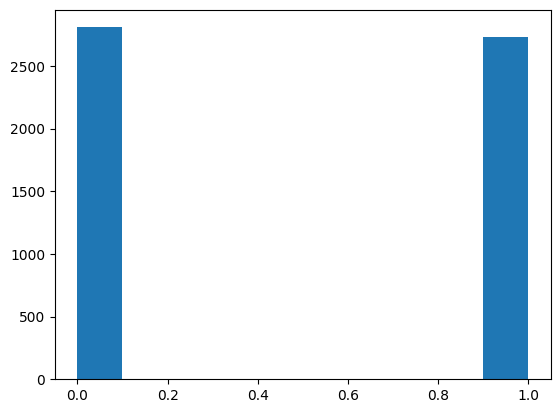

In [79]:
plt.hist(y_train)

In [80]:
model8 = SVC(kernel='rbf', gamma='scale', C = 5.0,probability=True)
model8.fit(X_train, y_train)

SVC(C=5.0, probability=True)

In [81]:
def metrics(y_test, y_pred):
    cf_matrix = confusion_matrix(y_test, y_pred, labels=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
    ac_score = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    return cf_matrix, ac_score, prec, rec, f1

In [82]:
y_pred = model8.predict(X_test)

In [83]:
hog_metr = metrics(y_test, y_pred)

print(f"Accuracy Score with HOG features: {hog_metr[1]}")
print(f"Precision with HOG features: {hog_metr[2]}")
print(f"Recall with HOG features: {hog_metr[3]}")
print(f"F1 Score with HOG features: {hog_metr[4]}")

Accuracy Score with HOG features: 0.9956678700361011
Precision with HOG features: 0.9956720134769026
Recall with HOG features: 0.9956678700361011
F1 Score with HOG features: 0.9956678655192878


In [84]:
image_to_test = cv2.imread('./data/BDD_photos/highway.jpg')
image_to_test = cv2.cvtColor(image_to_test, cv2.COLOR_BGR2RGB)
image_rgb = cv2.cvtColor(image_to_test, cv2.COLOR_BGR2GRAY)

In [85]:
def sliding_window(image, window, step):
    for y in range(0, image.shape[0] - window[1], step):
        for x in range(0, image.shape[1] - window[0], step):
            yield (x, y, image[y:y + window[1], x:x + window[0]])

In [86]:
import time


In [87]:
(window_w, window_h) = (64,64)

# For using without SIFT

In [88]:
def create_bbox(image_gr, image_rgb): # для одного размера окошка
    heatmap = np.zeros((720,1280))
    for (x, y, window) in sliding_window(image_gr, (window_w, window_h), 20):
        if window.shape[0] != window_w or window.shape[1] != window_h:
            continue
        
        clone = image_gr.copy()
        inside = clone[y:y + window_h, x:x + window_w]
        im = cv2.resize(inside, (64,64))
        fd,_ = hog(im, orientations=9, pixels_per_cell=(8, 8), 
                    cells_per_block=(2, 2), visualize=True)
    
        pred = model8.predict_proba([fd])
        if pred[0][1] > 0.95:
            heatmap[y:y + window_w, x:x + window_w] += 10*pred[0][1]
    ret, thresh1 = cv2.threshold(heatmap, 150, 255, cv2.THRESH_BINARY) 
    contours, hierarchy = cv2.findContours(thresh1.astype('uint8'), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(image_rgb, (x, y), (x + w, y + h), (0, 255, 0), 2)
    return image_rgb


In [89]:
def func_3_wind(image,model): # 3 размера окошка. строит heatmap (3 шт) и складывает их, устанавливая разные threshold
    heatmap70 = np.zeros((720,1280))
    heatmap140 = np.zeros((720,1280))
    heatmap200 = np.zeros((720,1280))

    window_w, window_h, step, weight = 70,70,10,50
    heatmap70 = take_heatmap(image,model,window_w,window_h,step,weight)

    window_w, window_h,step, weight = 200,200,40,10
    heatmap200 = take_heatmap(image,model,window_w,window_h,step,weight)


    window_w, window_h, step, weight = 140,140,35,20
    heatmap140 = take_heatmap(image,model,window_w,window_h,step,weight)


    ret200, thresh200 = cv2.threshold(heatmap200, np.max(heatmap200)*0.7, 180, cv2.THRESH_BINARY) 
    ret140, thresh140 = cv2.threshold(heatmap140, np.max(heatmap140)*0.5, 120, cv2.THRESH_BINARY) 
    ret70, thresh70 = cv2.threshold(heatmap70, np.max(heatmap70)*0.6, 255, cv2.THRESH_BINARY) 
    heatmap_sum = thresh200 + thresh140 + thresh70
    ret, thresh_sum = cv2.threshold(heatmap_sum, np.max(heatmap_sum)*0.4, 255, cv2.THRESH_BINARY) 
    return thresh_sum

In [90]:
def take_heatmap(image,model,window_w,window_h,step,weight,prob = 0.95): # строит heatmap, проходя одним окошком
    heatmap = np.zeros((720,1280))
    for (x, y, window) in sliding_window(image, (window_w, window_h), 35):
        if window.shape[0] != window_w or window.shape[1] != window_h:
            continue
        
        clone = image.copy()
        inside = clone[y:y + window_h, x:x + window_w]
        im = cv2.resize(inside, (64,64))
        fd,_ = hog(im, orientations=9, pixels_per_cell=(8, 8), 
                    cells_per_block=(2, 2), visualize=True)
    
        pred = model.predict_proba([fd])
        if pred[0][1] > prob:
            heatmap[y:y + window_w, x:x + window_w] += weight
    return heatmap

In [91]:
def bbox_for_3_wind(image_gr, image_rgb,model): # строит bounding box по трем окошкам
    heatmap = np.zeros((720,1280))
    thresh_3w = func_3_wind(image_gr,model)

    contours, hierarchy = cv2.findContours(thresh_3w.astype('uint8'), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(image_rgb, (x, y), (x + w, y + h), (0, 255, 0), 2)
    return image_rgb, thresh_3w


In [92]:
img_boxes,img_tr = bbox_for_3_wind(image_rgb,image_to_test,model8)

/home/mary/.local/lib/python3.10/site-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Float image out of standard range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


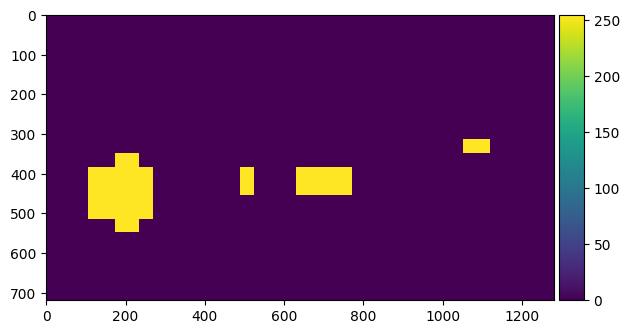

In [93]:
imshow(img_tr)

In [94]:
#(window_w, window_h) = (200,200)

In [95]:
#imshow(create_bbox(image_rgb,image_to_test))


In [96]:
# filename = './SanFrancisco_cut.mp4'
# cap = cv2.VideoCapture(filename)

# framesize = (int(1280), int(720))
# fourcc = cv2.VideoWriter.fourcc(*'XVID')
# out = cv2.VideoWriter(f"SF_3_bbox.avi", fourcc, 30.0, framesize, isColor=True)

# if (cap.isOpened()== False): 
#   print("Error opening video stream or file")
    
# while(cap.isOpened()):
#     ret, frame = cap.read()
#     if ret == True:
#         img_gr = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
#         frame = bbox_for_3_wind(img_gr,frame)
#         out.write(frame)
    
#     else: 
#         break
 
# cap.release()
# cv2.destroyAllWindows()


# SIFT

In [97]:
def compute_sift_features(img, ndes=10):

    descr = np.zeros((ndes, 128), dtype=np.float64)
    sift = cv2.SIFT_create(ndes)
    kp, des = sift.detectAndCompute(img, None)
 
    if des is not None:  
        descr[:des.shape[0]] = des[:ndes]
    descr = descr / (np.max(descr) + np.finfo(np.float32).eps)
    
    return descr

In [98]:
def process_images_from_folder_HOG_SIFT(folder_path):
    image_vectors = []
    file_names = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
    
    for file_name in file_names:
        file_path = os.path.join(folder_path, file_name)
        try:
            image = imread(file_path)

            image = cv2.resize(image, (64,64))
            image_gr = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            sift_features = compute_sift_features(image)

            #print(image.ravel().shape)
            fd, hog_image = hog(image_gr, orientations=9, pixels_per_cell=(8, 8), 
                    cells_per_block=(2, 2), visualize=True)
            #d = np.concatenate(image.ravel(),fd)
            #print(np.ravel(sift_features).shape)
            d = np.array(fd)
            image_vectors.append(np.concatenate((d,np.ravel(np.array(sift_features)))))
        except Exception as e:
            print(f"Ошибка при обработке файла {file_name}: {e}")
            
    return image_vectors


In [99]:
view = {0 : 'Far', 1 : 'Left', 2 : 'MiddleClose', 3 : 'Right'}
path = './data/non-vehicles/'
res_non_vehicle_HOG_sf = []
for cls in view:
    path_using = path + view[cls] + '/'
    res_non_vehicle_HOG_sf += process_images_from_folder_HOG_SIFT(path_using)
res_non_vehicle_HOG_sf

[array([0.40411276, 0.01150789, 0.00727823, ..., 0.        , 0.        ,
        0.        ]),
 array([0.00246975, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]),
 array([0.07832545, 0.01207869, 0.02119701, ..., 0.        , 0.        ,
        0.        ]),
 array([0.30927566, 0.11235098, 0.10860071, ..., 0.04054054, 0.02702703,
        0.        ]),
 array([0.27012106, 0.09927886, 0.02054477, ..., 0.0530303 , 0.10606061,
        0.03787879]),
 array([0.06601663, 0.02348404, 0.07013885, ..., 0.045     , 0.        ,
        0.015     ]),
 array([0.05197429, 0.02998879, 0.14206891, ..., 0.        , 0.        ,
        0.14375   ]),
 array([0.09574242, 0.05765934, 0.04355734, ..., 0.        , 0.        ,
        0.        ]),
 array([0.07656875, 0.        , 0.03284278, ..., 0.        , 0.        ,
        0.        ]),
 array([0.30049715, 0.01414555, 0.        , ..., 0.        , 0.        ,
        0.        ]),
 array([0.29659632, 0.        , 0.23534909, ..., 0

In [100]:
res_non_vehicle_HOG_sf += process_images_from_folder_HOG_SIFT(("/home/mary/.cache/kagglehub/datasets/antigs/skyimage-dataset/versions/1/swimseg-2/train"))

In [101]:
view = {0 : 'Far', 1 : 'Left', 2 : 'MiddleClose', 3 : 'Right'}
path = './data/vehicles/'
res_vehicle_HOG_sf = []
for cls in view:
    path_using = path + view[cls] + '/'
    res_vehicle_HOG_sf += process_images_from_folder_HOG_SIFT(path_using)
res_vehicle_HOG_sf

[array([0.11470312, 0.19084561, 0.0638807 , ..., 0.31067961, 0.        ,
        0.        ]),
 array([0.06149741, 0.00787337, 0.00308819, ..., 0.        , 0.        ,
        0.        ]),
 array([0.20034365, 0.        , 0.17714088, ..., 0.        , 0.        ,
        0.        ]),
 array([0.02445207, 0.        , 0.0191601 , ..., 0.        , 0.02484472,
        0.20496894]),
 array([0.0476434 , 0.        , 0.00257538, ..., 0.        , 0.        ,
        0.07432432]),
 array([0.02528397, 0.        , 0.01652832, ..., 0.00666667, 0.00666667,
        0.        ]),
 array([0.01657783, 0.        , 0.02742416, ..., 0.0070922 , 0.0070922 ,
        0.04255319]),
 array([0.02838823, 0.01828212, 0.02863013, ..., 0.        , 0.        ,
        0.        ]),
 array([0.07145503, 0.04173725, 0.25211877, ..., 0.        , 0.06289308,
        0.38993711]),
 array([0.01026594, 0.01686567, 0.04528761, ..., 0.01123596, 0.11235955,
        0.03370787]),
 array([0.11641803, 0.05355451, 0.05431297, ..., 0

In [121]:
import random
random.shuffle(res_non_vehicle_HOG_sf)
res_non_vehicle_HOG_sf = res_non_vehicle_HOG_sf[:3500]

In [122]:
res_non_vehicle_HOG_sf = np.array(res_non_vehicle_HOG_sf)
res_vehicle_HOG_sf = np.array(res_vehicle_HOG_sf)
res_non_vehicle_HOG_sf.shape

(3500, 3044)

In [123]:
y_sf = np.concatenate((np.ones(res_vehicle_HOG_sf.shape[0]), np.zeros(res_non_vehicle_HOG_sf.shape[0])))

In [124]:
X_sf = np.vstack((res_vehicle_HOG_sf, res_non_vehicle_HOG_sf))

In [125]:
X_sf_train, X_sf_test, y_sf_train, y_sf_test = train_test_split(X_sf, y_sf, test_size=0.2, random_state=42, shuffle=True)

In [126]:
model9 = SVC(kernel='rbf', gamma='scale', C = 5.0, probability=True)
model9.fit(X_sf_train, y_sf_train)

SVC(C=5.0, probability=True)

In [127]:
y_pred_sf = model9.predict(X_sf_test)

In [128]:
hog_metr_sf = metrics(y_sf_test, y_pred_sf)

print(f"Accuracy Score with HOG and SIFT features: {hog_metr_sf[1]}")
print(f"Precision with HOG and SIFT features: {hog_metr_sf[2]}")
print(f"Recall with HOG and SIFT features: {hog_metr_sf[3]}")
print(f"F1 Score with HOG and SIFT features: {hog_metr_sf[4]}")

Accuracy Score with HOG and SIFT features: 0.9884476534296028
Precision with HOG and SIFT features: 0.9884476534296028
Recall with HOG and SIFT features: 0.9884476534296028
F1 Score with HOG and SIFT features: 0.9884476534296028


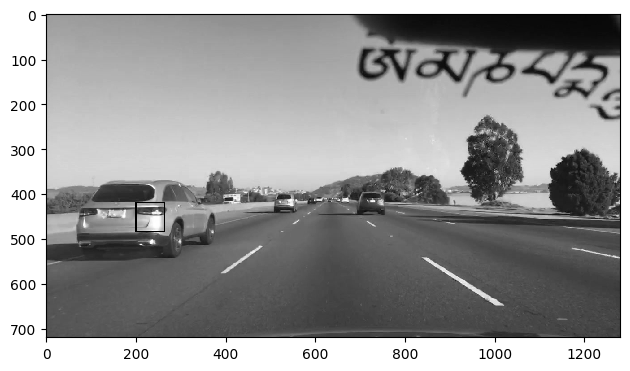

In [ ]:
pred_0 = 0
heatmap = np.zeros((720,1280))
for (x, y, window) in sliding_window(image_rgb, (window_w, window_h), 20):
    if window.shape[0] != window_w or window.shape[1] != window_h:
        continue
        
    clone = image_rgb.copy()
    inside = clone[y:y + window_h, x:x + window_w]
    #print(inside.shape)
    im = cv2.resize(inside, (64,64))
    #imshow(im)
    fd, hog_image = hog(im, orientations=9, pixels_per_cell=(8, 8), 
                    cells_per_block=(2, 2), visualize=True)
            #d = np.concatenate(image.ravel(),fd)
    sift_features = compute_sift_features(image_to_test[y:y + window_h, x:x + window_w])


    image_vectors = np.concatenate((fd,np.ravel(np.array(sift_features))))
    pred = model9.predict_proba([image_vectors])
    if pred[0][1] > 0.95:
        color = (255)
        heatmap[y:y + window_w, x:x + window_w] += 10*pred[0][1]
    else:
        color = (0)
    pred_0 = pred[0][1]

    cv2.rectangle(clone, (x, y), (x + window_w, y + window_h), color, 2)
    #clone = clone[:,:]
    imshow(clone)
    plt.pause(0.001) 
    display.clear_output(wait=True)

In [ ]:
imshow(heatmap/10)

# Тупо тестим на одной

In [ ]:
pred_0 = 0
heatmap = np.zeros((720,1280))
for (x, y, window) in sliding_window(image_rgb, (window_w, window_h), 20):
    if window.shape[0] != window_w or window.shape[1] != window_h:
        continue
        
    clone = image_rgb.copy()
    inside = clone[y:y + window_h, x:x + window_w]
    #print(inside.shape)
    im = cv2.resize(inside, (64,64))
    #imshow(im)
    fd, hog_image = hog(im, orientations=9, pixels_per_cell=(8, 8), 
                    cells_per_block=(2, 2), visualize=True)
            #d = np.concatenate(image.ravel(),fd)
    arr = fd
    
    pred = model8.predict_proba([arr])
    #print(pred)
    if pred[0][1] > 0.7 and pred_0 > 0.9 or pred[0][1] > 0.95:
        color = (255)
        heatmap[y:y + window_h, x:x + window_w] += 10*pred[0][1]
    else:
        color = (0)
    pred_0 = pred[0][1]
    #pred = model3.predict([arr])
    #if pred[0] == 1:
       # color = (255,0,0)
       # heatmap[y:y + window_h, x:x + window_w] += 10
   # else:
    #    color = (0,255,0)
    cv2.rectangle(clone, (x, y), (x + window_w, y + window_h), color, 2)
    clone = clone[:,:]
    imshow(clone)
    plt.pause(0.001) 
    display.clear_output(wait=True)
